# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is considered linear when its parameters are linear. (linear in its parameters). 
2. The coefficient for a dummy variable represents the difference in the predicted outcome between a given category and the reference category. This helps determine the predicted value for the reference group. 
3. No, linear regression is not appropriate for classification as it doesn't adequately model probabilities. 
4. Signs of overfitting include a model that performs well on training data but poorly on independent test data. This is due to the model learning on the general noise of the training data rather than general patterns. Additionally, overfitting can cause high sensitivity to small changes in data as well. 
5. Multicollinearity occurs when independent variables are highly correlated, meaning one can be linearly predicted from others with high accuracy. This makes it difficult to estimate their individual effects reliably, since their impacts on the dependent variable are not clearly separated. In 2SLS, one of the correlated variables is first regressed on other variables to isolate the variation that is not correlated with the others. Then, in the second stage, the original dependent variable is regressed on these predicted values to lead to a more stable estimate. 
6. Nonlinear relationships can be incorporated by transforming input variables while keeping coefficients linear. For example, one could conduct transformations such as logs or ln.
7. The slope coefficient represents the expected change in the Y variable resulting from a 1 unit increase in X. The remaining independent variables will be held constant.
8. A train/test split divides the data into training and testing data before applying it to a model. On the other hand, k-fold cross-validation divides the data into k subsets and evaluates the model multiple times. This proves to be a more reliable and consistent estimate. 
9. The value of k is chosen based on the accuracy and efficiency to reduce bias. Typical numbers include 5 or 10 to reduce the effect of the tradeoff.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("./data/Q1_clean.csv")
df = df.rename(columns={
    "Review Scores Rating": "ReviewScoresRating","Neighbourhood ": "Neighbourhood"})

df = df[["Price", "ReviewScoresRating", "Neighbourhood"]].dropna()
df["log_price"] = np.log(df["Price"])

                    Price  ReviewScoresRating
Neighbourhood                                
Bronx           75.276498           91.654378
Brooklyn       127.747378           92.363497
Manhattan      183.664286           91.801496
Queens          96.857233           91.549057
Staten Island  146.166667           90.843750
Most expensive neighbourhood: Manhattan


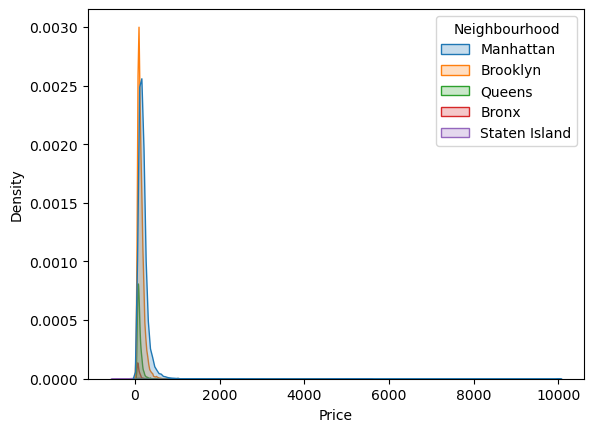

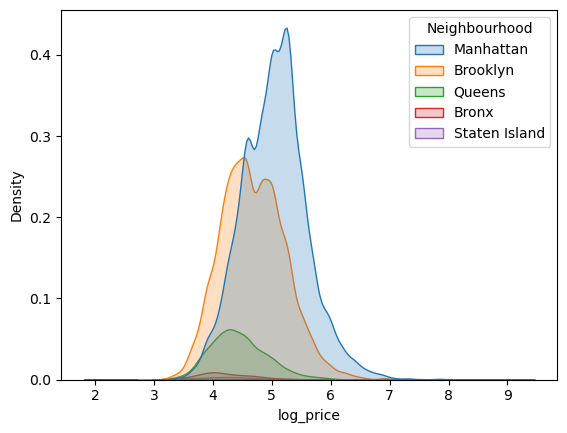

In [74]:
#1 
means = df.groupby("Neighbourhood")[["Price", "ReviewScoresRating"]].mean()
print(means)
print("Most expensive neighbourhood:", means["Price"].idxmax())

sns.kdeplot(data=df, x="Price", hue="Neighbourhood", fill=True)
plt.show()

sns.kdeplot(data=df, x="log_price", hue="Neighbourhood", fill=True)
plt.show()

In [75]:
#2 
X = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=float)
X = sm.add_constant(X)
y = df["Price"]
model = sm.OLS(y, X).fit()
print(model.summary())

'''The intercept represents the average price for the reference neighbourhood.
Each dummy variable represents the difference between the neighborhood's average price and the reference neighborhood's average price.
The regression coefficients are directly related to the group means. '''

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        18:51:47   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

"The intercept represents the average price for the reference neighbourhood.\nEach dummy variable represents the difference between the neighborhood's average price and the reference neighborhood's average price.\nThe regression coefficients are directly related to the group means. "

In [76]:
#3 
X = sm.add_constant(df["ReviewScoresRating"])
model2 = sm.OLS(y, X).fit()
print(model2.summary())
'''The slope coefficient shows the predicted change in price associated with a one-unit increase in the X variable (review score).'''


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        18:51:49   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 60.8784     10

'The slope coefficient shows the predicted change in price associated with a one-unit increase in the X variable (review score).'

In [77]:
#4
X = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=float)
X["ReviewScoresRating"] = df["ReviewScoresRating"]
X = sm.add_constant(X)

model3 = sm.OLS(y, X).fit()
print(model3.summary())
'''After adding the neighborhood variable, the slope coefficient may change because the model is now comparing new variables. The neighborhood coefficients represent differences in price across neighborhoods while holding the review score constant. '''

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        18:51:52   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -23.8126     14

'After adding the neighborhood variable, the slope coefficient may change because the model is now comparing new variables. The neighborhood coefficients represent differences in price across neighborhoods while holding the review score constant. '

In [78]:
#5 
X = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=float)
X["ReviewScoresRating"] = df["ReviewScoresRating"]
for col in pd.get_dummies(df["Neighbourhood"], drop_first=True).columns:
    X[f"{col}_interaction"] = X[col] * df["ReviewScoresRating"]
X = sm.add_constant(X)
model4 = sm.OLS(y, X).fit()
print(model4.summary())
'''This allows each neighborhood by have a different slope for each of the review scores.'''

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:51:54   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

'This allows each neighborhood by have a different slope for each of the review scores.'

In [60]:
#6 
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

y = df["Price"]
X3 = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=float)
X3["ReviewScoresRating"] = df["ReviewScoresRating"]

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=float)
X4 = dummies.copy()
X4["ReviewScoresRating"] = df["ReviewScoresRating"]

for col in dummies.columns:
    X4[f"{col}_x_score"] = dummies[col] * df["ReviewScoresRating"]
lr = LinearRegression()

cv_model3 = cross_val_score(lr, X3, y, cv=5, scoring="neg_mean_squared_error")
cv_model4 = cross_val_score(lr, X4, y, cv=5, scoring="neg_mean_squared_error")

print("Model 3 CV MSE:", -cv_model3.mean())
print("Model 4 CV MSE:", -cv_model4.mean())

'''I used the cross-validation and compared the average mean squared error across models. The model with the lower cross-validation MSE performs better on the unseen data'''

Model 3 CV MSE: 21113.112422262086
Model 4 CV MSE: 21418.246870450406


'I used the cross-validation and compared the average mean squared error across models. The model with the lower cross-validation MSE performs better on the unseen data'

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


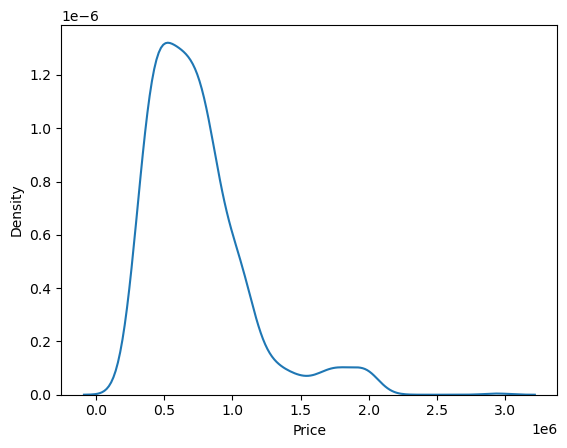

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


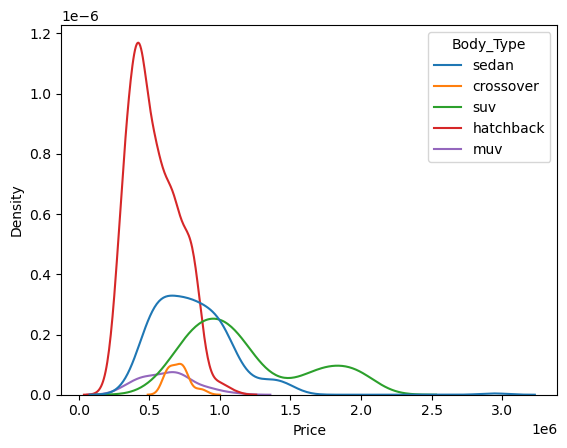

'The most expensive car type is the one with the highest average median price. This would be the SUV. The car with the most variance is the one with the highest standard deviation and the widest spread in the density plot. This would be the SUV also.  '

In [61]:
df = pd.read_csv("./data/cars_hw.csv")
#1
print(df["Price"].describe())
sns.kdeplot(data=df, x="Price")
plt.show()
print(df.groupby("Body_Type")["Price"].describe())
sns.kdeplot(data=df, x="Price", hue="Body_Type")
plt.show()
'''The most expensive car type is the one with the highest average median price. This would be the SUV. The car with the most variance is the one with the highest standard deviation and the widest spread in the density plot. This would be the SUV also.  '''

In [62]:
#2
y = df["Price"]
X = sm.add_constant(df["Seating_Capacity"])
model1 = sm.OLS(y, X).fit()
print(model1.summary())
'''The slope coefficient shows the change in the dependent variable for a one-unit change in the independent variable.It shows the predicted change in the price for one additional seat in the car.'''

X = pd.get_dummies(df["Seating_Capacity"], drop_first=True, dtype=float)
X = sm.add_constant(X)
model2 = sm.OLS(y, X).fit()
print(model2.summary())
'''Each seating capacity is its own category. If the coefficients increase as the number of seats rises, the relationship is roughly linear.'''

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        18:47:42   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

'Each seating capacity is its own category. If the coefficients increase as the number of seats rises, the relationship is roughly linear.'

In [63]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
#3
df["Age"] = df["Make_Year"].max() - df["Make_Year"]
X = df[["Age"]]
y = df["Price"]
cv_results = {}
for degree in range(1, 11):
    model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),
                          LinearRegression())
    scores = cross_val_score(model, X, y, cv=10, scoring="neg_mean_squared_error")
    cv_results[degree] = -scores.mean()
print(cv_results)

best_degree = min(cv_results, key=cv_results.get)
print(f"Best degree: {best_degree}")

'''Using 10-fold cross-validation to compare different models, I found that the optimal number of powers is the one with the lowest average cross-validated MSE'''

{1: np.float64(100295370079.45538), 2: np.float64(100814620596.42154), 3: np.float64(100380163091.91905), 4: np.float64(100474431121.1202), 5: np.float64(100131346195.58618), 6: np.float64(100347765584.09091), 7: np.float64(99809273329.14305), 8: np.float64(99350288096.022), 9: np.float64(99043885733.05367), 10: np.float64(99176465396.12823)}
Best degree: 9


'Using 10-fold cross-validation to compare different models, I found that the optimal number of powers is the one with the lowest average cross-validated MSE'

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


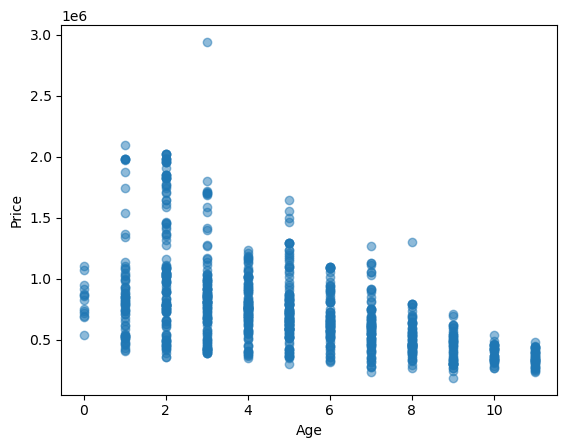

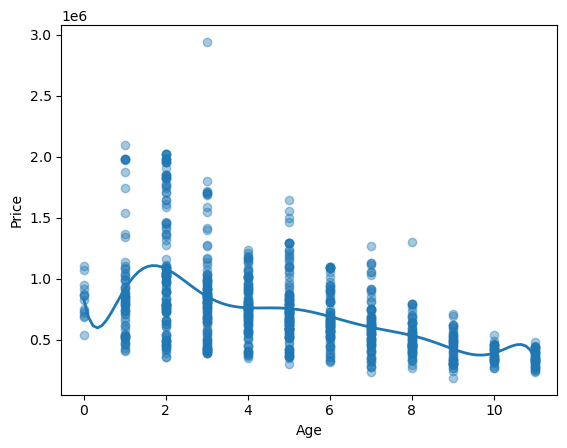

"The scatterplot shows the relationship between price and age. The fitted line shows the model's predicted values. If the fitted line follows the main data, then the model has great accuracy. According to the graph, the model accurately fits the patterns in the data. "

In [64]:
#4
best_model = make_pipeline(PolynomialFeatures(degree=best_degree, include_bias=False),                           LinearRegression())
best_model.fit(X, y)
age = np.linspace(df["Age"].min(), df["Age"].max(), 100).reshape(-1, 1)
predicted_prices = best_model.predict(age)

plt.scatter(df["Age"], df["Price"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

plt.scatter(df["Age"], df["Price"], alpha=0.4)
plt.plot(age, predicted_prices, linewidth=2)
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

'''The scatterplot shows the relationship between price and age. The fitted line shows the model's predicted values. If the fitted line follows the main data, then the model has great accuracy. According to the graph, the model accurately fits the patterns in the data. '''

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [65]:
df = pd.read_csv("./data/heart_hw.csv")
print(df.head())
#1
survival_rates = df.groupby("transplant")["y"].mean()
print(survival_rates)
ate = survival_rates["treatment"] - survival_rates["control"]
print("Average Treatment Effect (ATE):", ate)
'''The proportion of patients surviving in the control group is .1176 while the proportion in the treatment group is .3478. The ATE is the difference between the two, being .2302. This means that receiving the heart transplant increases the probability of surviving 3 years by .2302.'''

   Unnamed: 0  age transplant  y
0           1   53    control  0
1           2   43    control  0
2           3   52    control  0
3           4   52    control  0
4           5   54    control  0
transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
Average Treatment Effect (ATE): 0.23017902813299232


'The proportion of patients surviving in the control group is .1176 while the proportion in the treatment group is .3478. The ATE is the difference between the two, being .2302. This means that receiving the heart transplant increases the probability of surviving 3 years by .2302.'

In [66]:
#2
X = pd.get_dummies(df["transplant"], drop_first=True, dtype=float)
X = sm.add_constant(X)
y = df["y"]
model = sm.OLS(y, X).fit()
print(model.summary())

'''The intercept is .1176 and the coefficient on the treatment is .2303. The intercept represents the average rate of survival for the control group. The coefficient on treatment represents the difference in survival rates between the treatment and control groups.This is the ATE.'''

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        18:47:42   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1176      0.075      1.574      0.1

'The intercept is .1176 and the coefficient on the treatment is .2303. The intercept represents the average rate of survival for the control group. The coefficient on treatment represents the difference in survival rates between the treatment and control groups.This is the ATE.'

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        18:47:42   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7020      0.196      3.583      0.0

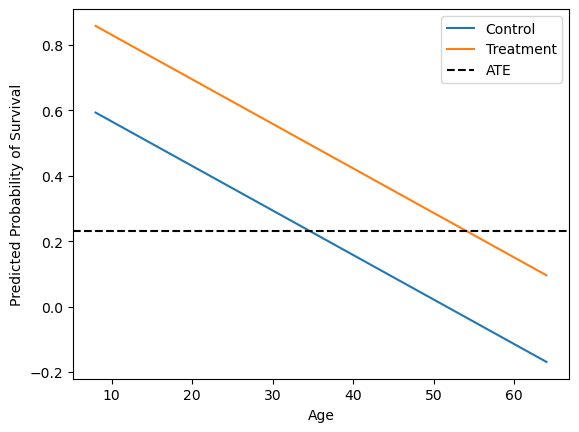

'The coefficient treatment is .2647 which is larger than the ATE of .2302. This suggests that age may have been a confounding variable. The intercept .7020 represents the predicted probability of survival for the control group individual with an age of 0. This serves as a baseline for the model. The coefficient on age -.0136 means that for each additional year of age, the predicted probability of surviving three years decreases by around .0136. ATE underestimates the effect in this situation. '

In [67]:
#3
X = pd.get_dummies(df["transplant"], drop_first=True, dtype=float)
X["age"] = df["age"]
X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()
print(model2.summary())

age_grid = np.linspace(df["age"].min(), df["age"].max(), 100)
control_pred = model2.predict(pd.DataFrame({
    "const": 1,
    "treatment": 0,
    "age": age_grid
}))
treatment_pred = model2.predict(pd.DataFrame({
    "const": 1,
    "treatment": 1,
    "age": age_grid
}))

plt.plot(age_grid, control_pred, label="Control")
plt.plot(age_grid, treatment_pred, label="Treatment")
plt.axhline(ate, linestyle="--", color="black", label="ATE")
plt.xlabel("Age")
plt.ylabel("Predicted Probability of Survival")
plt.legend()
plt.show()

'''The coefficient treatment is .2647 which is larger than the ATE of .2302. This suggests that age may have been a confounding variable. The intercept .7020 represents the predicted probability of survival for the control group individual with an age of 0. This serves as a baseline for the model. The coefficient on age -.0136 means that for each additional year of age, the predicted probability of surviving three years decreases by around .0136. ATE underestimates the effect in this situation. '''

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        18:47:42   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.3549      0.280      1.269

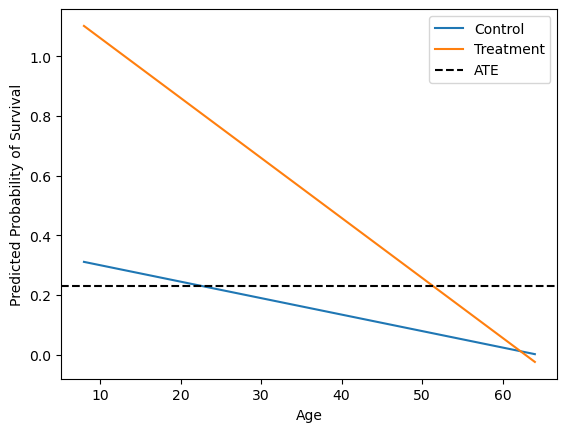

'The interaction term is -.0146 and shows that the treatment effect decreases with age. This means that the transplants are more beneficial for younger patients.'

In [68]:
#4
df["treatment"] = (df["transplant"] == "treatment").astype(int)
df["treatment_age"] = df["treatment"] * df["age"]
X = df[["treatment", "age", "treatment_age"]]

X = sm.add_constant(X)
model3 = sm.OLS(y, X).fit()
print(model3.summary())

age_grid = np.linspace(df["age"].min(), df["age"].max(), 100)
control_pred = model3.predict(pd.DataFrame({
    "const": 1,
    "treatment": 0,
    "age": age_grid,
    "treatment_age": 0
}))
treatment_pred = model3.predict(pd.DataFrame({
    "const": 1,
    "treatment": 1,
    "age": age_grid,
    "treatment_age": age_grid
}))
plt.plot(age_grid, control_pred, label="Control")
plt.plot(age_grid, treatment_pred, label="Treatment")
plt.axhline(ate, linestyle="--", color="black", label="ATE")
plt.xlabel("Age")
plt.ylabel("Predicted Probability of Survival")
plt.legend()
plt.show()

'''The interaction term is -.0146 and shows that the treatment effect decreases with age. This means that the transplants are more beneficial for younger patients.'''

In [69]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
#5 
X1 = pd.get_dummies(df["transplant"], drop_first=True, dtype=float)
X2 = pd.get_dummies(df["transplant"], drop_first=True, dtype=float)
X2["age"] = df["age"]
X3 = df[["treatment", "age", "treatment_age"]]
lr = LinearRegression()
cv1 = cross_val_score(lr, X1, y, cv=5, scoring="neg_mean_squared_error")
cv2 = cross_val_score(lr, X2, y, cv=10, scoring="neg_mean_squared_error")
cv3 = cross_val_score(lr, X3, y, cv=10, scoring="neg_mean_squared_error")
print("Model 1 CV MSE:", -cv1.mean())
print("Model 2 CV MSE:", -cv2.mean())
print("Model 3 CV MSE:", -cv3.mean())



Model 1 CV MSE: 0.21471121108703714
Model 2 CV MSE: 0.19922806049232317
Model 3 CV MSE: 0.19609811380122746


#6 
Some concerns that may occur are variables that may have been omitted that affect both transplant and survival rate, and therefore confound the information found by the model. Additionally, the model could demonstrate inequalities within certain groups if used to prioritize access based on the data that it is given. Such a model would be unethical to use for sensitive and life-altering medical decisions. Additionally, clinics could be seen as not transparent, unfair, and discriminatory through confusing correlation with causation caused by some of the data.